<a href="https://colab.research.google.com/github/michalejan/EEG-Neural-Representation-Prediciton-Model_BA/blob/main/EEG_preprocessing_allsubs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Data loading and environment setup

In [1]:
!pip install openneuro-py mne pandas

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import openneuro
import pandas as pd
import mne
import glob

# target directory
base_path = '/content/drive/MyDrive/EEG_data/full_subject_list'

# create the directory if it doesn't exist
if not os.path.exists(base_path):
    os.makedirs(base_path)

# downloading the dataset
openneuro.download(dataset='ds004771', target_dir=base_path)


👋 Hello! This is openneuro-py 2026.3.1. Great to see you! 🤗

   👉 Please report problems 🤯 and bugs 🪲 at
      https://github.com/hoechenberger/openneuro-py/issues

🌍 Preparing to download ds004771 …


📁 Traversing directories for ds004771 : 0 entities [00:00, ? entities/s]

📥 Retrieving up to 331 files (5 concurrent downloads). 
✅ Finished downloading ds004771.
 
🧠 Please enjoy your brains.
 


# 2. Testing the pipeline on SUB-001

In [10]:
# STEP 1: test loading the first subject's continuous data
if good_subjects:
    test_sub = good_subjects[0]
    print(f"\nAttempting to load epoched data for: {test_sub}")

    sub_folder = os.path.join(base_path, test_sub)
    # .set file
    set_files = glob.glob(os.path.join(sub_folder, '**', '*.set'), recursive=True)

    if set_files:
        epochs = mne.read_epochs_eeglab(set_files[0], verbose='error')

        epochs.load_data()

        print("\n Successful loading! Epoched data loaded into RAM.")

        print(epochs.info)

        # STEP 2: spatial cleaning and filtering
        print("\nSTEP 2: spatial cleaning and filtering")

        # 1. Common Average Reference (CAR)
        epochs.set_eeg_reference('average', projection=False, verbose=True)

        # 2. Bandpass Filter (0.1 Hz to 30.0 Hz)
        epochs.filter(l_freq=0.1, h_freq=30.0, verbose=True)

        print("\n Step 2 Complete: Data is re-referenced and filtered.")

    else:
        print(f"XXXXX Error: No .set file found in {sub_folder} XXXXXX")


Attempting to load epoched data for: sub-001

 Successful loading! Epoched data loaded into RAM.
<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, AF3, F7, F3, FC1, FC5, T7, C3, CP1, CP5, P7, P3, Pz, PO3, ...
 chs: 34 EEG
 custom_ref_applied: False
 dig: 37 items (3 Cardinal, 34 EEG)
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: unspecified
 nchan: 34
 projs: []
 sfreq: 256.0 Hz
>

STEP 2: spatial cleaning and filtering
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Setting up band-pass filter from 0.1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff 

/tmp/ipykernel_2867/4089778465.py:26: RuntimeWarning: filter_length (8449) is longer than the signal (334), distortion is likely. Reduce filter length or filter a longer signal.
  epochs.filter(l_freq=0.1, h_freq=30.0, verbose=True)



 Step 2 Complete: Data is re-referenced and filtered.


In [15]:
from mne.preprocessing import ICA

print("\n STEP 3: ICA for Ocular Artifact Removal")

# 1. initialize the ICA model
ica = ICA(n_components=15, method='fastica', random_state=42)

# 2. fitting the ICa to the filtered epochs
print("Fitting ICA to the data:")
ica.fit(epochs)

# 3. detecting eye blinks
print("Searching for eye blink components using electrode Fp1")
eog_indices, eog_scores = ica.find_bads_eog(epochs, ch_name='Fp1',threshold=2.0, verbose=False)

# excluding the eye blinks
ica.exclude = eog_indices

print(f"----- Automatically identified and flagged {len(eog_indices)} blink component(s): {eog_indices}")

# 4. applying ICA to a copy of the data
epochs_clean = ica.apply(epochs.copy(), verbose=False)

print("\n Step 3 Complete: ICA applied and blinks removed from the brainwaves.")


 STEP 3: ICA for Ocular Artifact Removal
Fitting ICA to the data:
Fitting ICA to data using 34 channels (please be patient, this may take a while)
Selecting by number: 15 components
Fitting ICA took 13.0s.
Searching for eye blink components using electrode Fp1
----- Automatically identified and flagged 3 blink component(s): [np.int64(1), np.int64(0), np.int64(3)]

 Step 3 Complete: ICA applied and blinks removed from the brainwaves.


In [18]:
#3 STEP 4: Trigger Mapping & Baselining
print("\n STEP 4: Trigger Mapping & Baselining")

# 1. apply Baseline Correction (-100ms to 0ms)
print("Applying baseline correction (-0.1 to 0.0s)...")
epochs_clean.apply_baseline(baseline=(-0.1, 0), verbose=False)

# 2. creating the dictionary with labels of triggers/stimuli
control_keys = [k for k in epochs_clean.event_id if '(110)' in k or '(115)' in k]
violation_keys = [k for k in epochs_clean.event_id if '(220)' in k or '(225)' in k]

print(f"Found Control markers: {control_keys}")
print(f"Found Violation markers: {violation_keys}")

# 3. filtering the dataset only for VIOLATION/CONTROL trials
target_keys = control_keys + violation_keys
epochs_target = epochs_clean[target_keys]

print(f"\n----- Step 4 Complete: Filtered down to {len(epochs_target)} target trials.")
print(epochs_target)
num_ctrl = len(epochs_target[control_keys])
num_viol = len(epochs_target[violation_keys])

print(f"   Control (Target) Trials: {num_ctrl}")
print(f"   Violation (Target) Trials: {num_viol}")




 STEP 4: Trigger Mapping & Baselining
Applying baseline correction (-0.1 to 0.0s)...
Found Control markers: ['B1,3,5,13(110)/B17,19,21,29(111)', 'B1,3,5,9(115)/B17,19,21,25(116)']
Found Violation markers: ['B1,4,6,14(220)/B17,20,22,30(221)', 'B1,4,6,10(225)/B17,20,22,26(226)']

----- Step 4 Complete: Filtered down to 80 target trials.
<EpochsEEGLAB | 80 events (all good), -0.102 – 1.199 s (baseline -0.1 – 0 s), ~7.0 MiB, data loaded,
 'B1,3,5,13(110)/B17,19,21,29(111)': 20
 'B1,4,6,14(220)/B17,20,22,30(221)': 20
 'B1,3,5,9(115)/B17,19,21,25(116)': 20
 'B1,4,6,10(225)/B17,20,22,26(226)': 20>
   Control (Target) Trials: 40
   Violation (Target) Trials: 40


In [20]:
# STEP 5: Resampling + final Amp thresh.
print("\n STEP 5: Resampling & Final Amplitude Thresholding")

# 1. Resample to 100 Hz: to compress the trials for the ML models
print(f"Original sampling rate: {epochs_target.info['sfreq']} Hz")
epochs_target.resample(100.0, verbose=False)
print(f"New sampling rate: {epochs_target.info['sfreq']} Hz")

# 2. Final Artifact Rejection
reject_criteria = dict(eeg=150e-6)  # 150 µV
epochs_target.drop_bad(reject=reject_criteria, verbose=True)

# final retention of trials
final_count = len(epochs_target)
print(f"\n----- Step 5 Complete: {final_count} good trials ready for ML classification.")


 STEP 5: Resampling & Final Amplitude Thresholding
Original sampling rate: 100.0 Hz
New sampling rate: 100.0 Hz
0 bad epochs dropped

----- Step 5 Complete: 79 good trials ready for ML classification.


### VISUALS FOR SUB-001


 STEP 6: Visualizing the P600 for sub-001
combining channels using "mean"
combining channels using "mean"


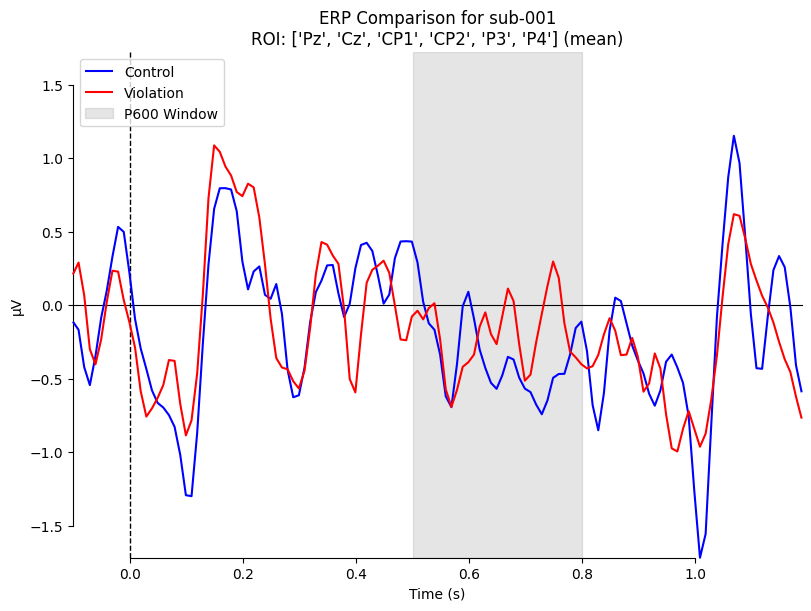

In [21]:
import matplotlib.pyplot as plt

print("\n STEP 6: Visualizing the P600 for sub-001")

# 1. computing the evoked averages for both conditions
evoked_ctrl = epochs_target[control_keys].average()
evoked_viol = epochs_target[violation_keys].average()

# 2. ROI for the P600 - centro-parietal areas
roi = ['Pz', 'Cz', 'CP1', 'CP2', 'P3', 'P4']

# dict
evokeds_dict = {
    'Control': evoked_ctrl,
    'Violation': evoked_viol
}

# 3. generate the plot
figs = mne.viz.plot_compare_evokeds(
    evokeds_dict,
    picks=roi,
    combine='mean',
    colors={'Control': 'blue', 'Violation': 'red'},
    linestyles={'Control': '-', 'Violation': '-'},
    title=f'ERP Comparison for {test_sub}\nROI: {roi}',
    show_sensors=False,
    legend='upper left',
    time_unit='s',
    show=False
)

# 4. highligting the P600 window
for f in figs:
    for ax in f.axes:
        ax.axvspan(0.5, 0.8, color='gray', alpha=0.2, label='P600 Window')
        ax.legend(loc='upper left')

plt.show()

# 3. Master Preprocessing Batch Loop

In [22]:
import os
import glob
import mne
import pandas as pd

print("------- STARTING THE MASTER PREPROCESSING BATCH LOOP ------- \n")

# Directories
base_path = '/content/drive/MyDrive/EEG_data/full_subject_list'
save_path = '/content/drive/MyDrive/EEG_data/P600_Results/ML_Ready_FIFs'
if not os.path.exists(save_path):
    os.makedirs(save_path)

# LOADING ALL GOOD SUBJECTS
tsv_path = os.path.join(base_path, 'participants.tsv')
meta_df = pd.read_csv(tsv_path, sep='\t')
good_subjects = meta_df[meta_df['data_usability'] == 'good']['participant_id'].tolist()
good_subjects.sort()

# STATS FOR THE FINAL CARD
report_card = []

for sub_id in good_subjects:
    print(f"🔄 Processing: {sub_id} ...")

    try:
        sub_folder = os.path.join(base_path, sub_id)
        set_files = glob.glob(os.path.join(sub_folder, '**', '*.set'), recursive=True)

        if not set_files:
            print(f"    Skipped: No .set file found.")
            continue

        # 2. Load data
        epochs = mne.read_epochs_eeglab(set_files[0], verbose='error')
        epochs.load_data()
        original_count = len(epochs)

        # 3. Spatial Cleaning & Filtering
        epochs.set_eeg_reference('average', projection=False, verbose=False)
        epochs.filter(l_freq=0.1, h_freq=30.0, verbose=False)

        # 4. ICA for Ocular Artifacts
        ica = mne.preprocessing.ICA(n_components=15, method='fastica', random_state=42)
        ica.fit(epochs, verbose=False)
        eog_indices, _ = ica.find_bads_eog(epochs, ch_name='Fp1', threshold=2.0, verbose=False)
        ica.exclude = eog_indices
        epochs_clean = ica.apply(epochs, verbose=False)

        # 5. Baselining & Trigger Mapping
        epochs_clean.apply_baseline(baseline=(-0.1, 0), verbose=False)

        ctrl_keys = [k for k in epochs_clean.event_id if '(110)' in k or '(115)' in k]
        viol_keys = [k for k in epochs_clean.event_id if '(220)' in k or '(225)' in k]
        target_keys = ctrl_keys + viol_keys
        epochs_target = epochs_clean[target_keys]

        # 6. Resampling & Amplitude Thresholding
        epochs_target.resample(100.0, verbose=False)
        epochs_target.drop_bad(reject=dict(eeg=150e-6), verbose=False)

        # 7. Save to .fif
        final_count = len(epochs_target)
        save_file = os.path.join(save_path, f"{sub_id}_ML_clean_epo.fif")
        epochs_target.save(save_file, overwrite=True, verbose=False)

        # Log stats
        retention_rate = (final_count / 80) * 100
        report_card.append({'Subject': sub_id, 'Final_Trials': final_count, 'Retention_%': round(retention_rate, 1)})
        print(f"   ✅ Done! Saved {final_count} trials.")

    except Exception as e:
        print(f"   XXXXXXXX ERROR on {sub_id}: {str(e)}")

# final report of the data
print("\n" + "="*40)
print("-------  BATCH PROCESSING COMPLETE------- ")
df_report = pd.DataFrame(report_card)

# double check for sub-059
if 'sub-059' in df_report['Subject'].values:
    sub_059_stats = df_report[df_report['Subject'] == 'sub-059']
    print(f"\n THE SUB-059 VERDICT:\n{sub_059_stats.to_string(index=False)}")

# double-check for trials with low retention (<40 trials)
bad_subjects = df_report[df_report['Final_Trials'] < 40]
if not bad_subjects.empty:
    print(f"\n-------  WARNING - Subjects with high data loss (<40 trials remaining):")
    print(bad_subjects.to_string(index=False))
else:
    print("\n All subjects with good retention")
print("="*40)

------- STARTING THE MASTER PREPROCESSING BATCH LOOP ------- 

🔄 Processing: sub-001 ...


/tmp/ipykernel_2867/2389796717.py:41: RuntimeWarning: filter_length (8449) is longer than the signal (334), distortion is likely. Reduce filter length or filter a longer signal.
  epochs.filter(l_freq=0.1, h_freq=30.0, verbose=False)


   ✅ Done! Saved 79 trials.
🔄 Processing: sub-002 ...


/tmp/ipykernel_2867/2389796717.py:41: RuntimeWarning: filter_length (8449) is longer than the signal (334), distortion is likely. Reduce filter length or filter a longer signal.
  epochs.filter(l_freq=0.1, h_freq=30.0, verbose=False)


   ✅ Done! Saved 79 trials.
🔄 Processing: sub-003 ...


...

   ✅ Done! Saved 80 trials.
🔄 Processing: sub-058 ...


/tmp/ipykernel_2867/2389796717.py:41: RuntimeWarning: filter_length (8449) is longer than the signal (334), distortion is likely. Reduce filter length or filter a longer signal.
  epochs.filter(l_freq=0.1, h_freq=30.0, verbose=False)


   ✅ Done! Saved 80 trials.
🔄 Processing: sub-059 ...


/tmp/ipykernel_2867/2389796717.py:41: RuntimeWarning: filter_length (8449) is longer than the signal (334), distortion is likely. Reduce filter length or filter a longer signal.
  epochs.filter(l_freq=0.1, h_freq=30.0, verbose=False)


   ✅ Done! Saved 79 trials.

-------  BATCH PROCESSING COMPLETE------- 

 THE SUB-059 VERDICT:
Subject  Final_Trials  Retention_%
sub-059            79         98.8

 All subjects with good retention


# 4. Visualizations

 Generating Grand Average ERP...
combining channels using "mean"
combining channels using "mean"


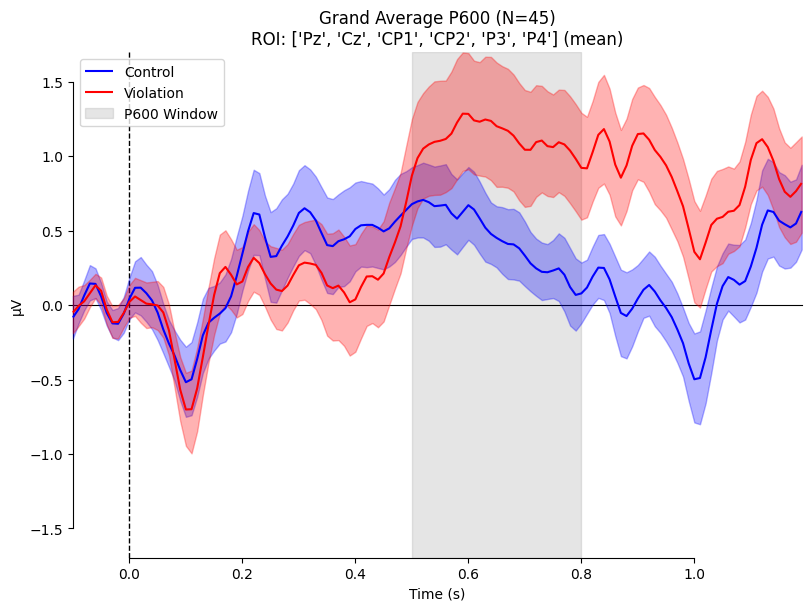

In [25]:
import os
import glob
import mne
import matplotlib.pyplot as plt

print(" Generating Grand Average ERP...")

results_path = '/content/drive/MyDrive/EEG_data/P600_Results/ML_Ready_FIFs'
fif_files = glob.glob(os.path.join(results_path, '*_ML_clean_epo.fif'))

all_evoked_ctrl = []
all_evoked_viol = []

for fname in fif_files:
    try:
        # loading the epochs
        epochs = mne.read_epochs(fname, preload=True, verbose=False)

        # triggers
        ctrl_keys = [k for k in epochs.event_id if '(110)' in k or '(115)' in k]
        viol_keys = [k for k in epochs.event_id if '(220)' in k or '(225)' in k]

        #averaging the trials for both triggers
        all_evoked_ctrl.append(epochs[ctrl_keys].average())
        all_evoked_viol.append(epochs[viol_keys].average())
    except Exception as e:
        print(f"Error loading {fname}: {e}")

# ROI (Centro-Parietal)
roi = ['Pz', 'Cz', 'CP1', 'CP2', 'P3', 'P4']

evokeds_dict = {
    'Control': all_evoked_ctrl,
    'Violation': all_evoked_viol
}

# Generate the plot
figs = mne.viz.plot_compare_evokeds(
    evokeds_dict,
    picks=roi,
    combine='mean',
    colors={'Control': 'blue', 'Violation': 'red'},
    linestyles={'Control': '-', 'Violation': '-'},
    ci=0.95,
    title=f'Grand Average P600 (N={len(all_evoked_ctrl)})\nROI: {roi}',
    show_sensors=False,
    legend='upper left',
    time_unit='s',
    show=False
)

# Highlight the P600 window
for f in figs:
    for ax in f.axes:
        ax.axvspan(0.5, 0.8, color='gray', alpha=0.2, label='P600 Window')
        ax.legend(loc='upper left')

plt.show()

🧠 Generating Topographic Maps...
Identifying common channels ...
Identifying common channels ...


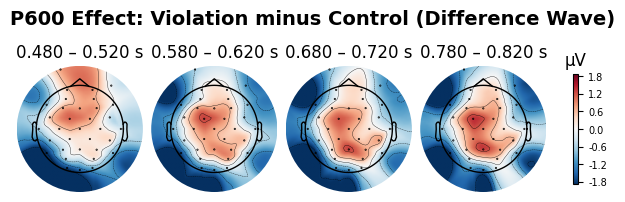

In [28]:
print("🧠 Generating Topographic Maps...")

# averaging all 45 particpants
ga_control = mne.grand_average(all_evoked_ctrl)
ga_violation = mne.grand_average(all_evoked_viol)

# calculating DIFFERENCE WAVE (Violation minus Control)
ga_difference = mne.combine_evoked([ga_violation, ga_control], weights=[1, -1])

# time poitns to focus on
times_to_plot = [0.5, 0.6, 0.7, 0.8]

# Plot the difference wave topography
fig_diff = ga_difference.plot_topomap(
    times=times_to_plot,
    ch_type='eeg',
    average=0.05,
    colorbar=True,
    show=False
)

fig_diff.suptitle('P600 Effect: Violation minus Control (Difference Wave)', fontsize=14, fontweight='bold')

plt.show()